In [ ]:
import numpy as np
from functools import lru_cache
from scipy import interpolate, integrate
import pandas as pd
import matplotlib.pyplot as plt
from time import time
# --------------------
# Globals & constants
# --------------------
np.seterr(over='warn', under='warn', divide='warn', invalid='warn')

GF = 1.16e-5
MW = 80.385
MZ = 91.1876
mu = 1e-3               # (1 MeV)/(T in MeV)
Mpl = 1.2e19
pi = np.pi
SQRT2 = np.sqrt(2.0)
ZETA3 = 1.2020569031595942854  # Apery's constant

# Precompute coefficient in V_T
_cV = (14.0 * SQRT2 * (pi**2) * GF) / 45.0 * (1.0 / (MZ**2) + 2.0 / (MW**2))

# --------------------
# Tables & interpolants
# --------------------
# (pandas deprecation: use sep=r'\s+')
tgH = pd.read_csv("GstarH.txt", sep=r"\s+", header=None).values
fgH = interpolate.interp1d(
    tgH[:, 0], tgH[:, 1], kind="linear", bounds_error=False, fill_value="extrapolate"
)

tgS = pd.read_csv("GstarS.txt", sep=r"\s+", header=None).values
fgS = interpolate.interp1d(
    tgS[:, 0], tgS[:, 1], kind="linear", bounds_error=False, fill_value="extrapolate"
)

def _clip_pos(x, tiny=1e-12):
    """Clip to strictly positive to avoid sqrt/zero issues."""
    return float(x) if x > tiny else tiny

# --------------------
# Stable helpers
# --------------------
def log1pexp_stable(x):
    # Underflow -> ~0; overflow-safe
    return np.logaddexp(0.0, x)

def BE_factor(E, T):
    # 1/(e^{E/T} - 1) with overflow safety
    y = E / T
    if y > 50.0:
        return 0.0
    # expm1 stable near 0
    return 1.0 / np.expm1(max(y, 1e-12))

def FD_factor(p, T):
    # 1/(e^{p/T} + 1) with symmetric overflow safety
    y = p / T
    if y > 50.0:
        return 0.0
    if y < -50.0:
        return 1.0
    if y >= 0.0:
        ey = np.exp(-y)     # <= 1, safe
        return ey / (1.0 + ey)
    else:
        ey = np.exp(y)      # <= 1, safe
        return 1.0 / (1.0 + ey)

# --------------------
# Rates / potentials
# --------------------
def Gamma_a(x, z):
    return (GF**2) * x * (mu**5) / (z**5)

def Gamma_phi(lambda_phi, m_phi):
    # (unused here, kept for completeness)
    return (lambda_phi**2) * m_phi / (32.0 * pi)

def n_phi(T):
    return 2.0 * ZETA3 * (T**3) / (pi**2)

_DEF_EPS = 1e-30  # tiny imaginary to keep logs off branch cut

def L1plus(omega, p, m_phi):
    a = -m_phi**2 - 4.0 * p * omega
    b = -m_phi**2
    return (np.log((a + 1j*_DEF_EPS) / (b + 1j*_DEF_EPS))
          + np.log((b + 1j*_DEF_EPS) / (b + 4.0 * p * omega + 1j*_DEF_EPS)))

def L2plus(omega, p, m_phi):
    E = np.sqrt(p*p + m_phi*m_phi)
    num1 = m_phi**2 + 2.0 * omega * E + 2.0 * p * omega
    den1 = m_phi**2 + 2.0 * omega * E - 2.0 * p * omega
    num2 = m_phi**2 - 2.0 * omega * E + 2.0 * p * omega
    den2 = m_phi**2 - 2.0 * omega * E - 2.0 * p * omega
    return (np.log((num1 + 1j*_DEF_EPS) / (den1 + 1j*_DEF_EPS))
          + np.log((num2 + 1j*_DEF_EPS) / (den2 + 1j*_DEF_EPS)))

def B_nocache(lam_phi, m_phi, omega, T, epsabs=1e-6, epsrel=1e-4):
    """Thermal loop integral B(ω,T)."""
    # Avoid 1/omega^2 singularity
    omega_safe = max(float(omega), 1e-12)
    # p integration bounds
    pmin = 1e-6
    upper = max(12.0 * T, pmin * (1.0 + 1e-6))
    if not np.isfinite(upper) or upper <= pmin:
        return 0.0

    def integrand(p):
        E = np.sqrt(p*p + m_phi*m_phi)
        term_BE = (m_phi*m_phi / 2.0) * (p / E) * L2plus(omega_safe, p, m_phi) - (4.0 * omega_safe * p*p) / E
        term_FD = (m_phi*m_phi / 2.0) * L1plus(omega_safe, p, m_phi) - 4.0 * omega_safe * p
        be = BE_factor(E, T)
        fd = FD_factor(p, T)
        return (term_BE * be + term_FD * fd).real

    # helpful breakpoints near characteristic thermal scales
    pts = []
    for k in (0.5, 1.0, 2.0, 4.0, 8.0, 12.0):
        xk = k * T
        if pmin < xk < upper:
            pts.append(xk)

    val, _ = integrate.quad(
        integrand, pmin, upper,
        epsabs=epsabs, epsrel=epsrel, limit=400,
        points=pts if pts else None
    )
    return (lam_phi**2) / (8.0 * (pi**2) * (omega_safe**2)) * val

# Quantized memoization for B to cut repeated work across similar (ω,T)
@lru_cache(maxsize=8192)
def _B_cached_quant(lam_phi, m_phi, omega_q, T_q):
    return B_nocache(lam_phi, m_phi, omega_q, T_q)

def B(lam_phi, m_phi, omega, T, epsabs=1e-6, epsrel=1e-4, quant=6):
    omega_q = float(np.round(omega, quant))
    T_q = float(np.round(T, quant))
    return _B_cached_quant(lam_phi, m_phi, omega_q, T_q)

def VT_new(lam_phi, m_phi, x, z):
    # ω = x μ / z, T = μ / z
    return -0.5 * B(lam_phi, m_phi, (x * mu) / z, mu / z)

def V_T(x, z):
    # original SM thermal potential
    return -_cV * x * (mu**5) / (z**5)

def Gamma_a_new(lambda_phi, m_phi, x, z):
    # add small-x safety
    x_safe = max(x, 1e-6)
    term1 = (7.0 * pi * x_safe * (lambda_phi**4) * (mu**5)) / (864.0 * (m_phi**4) * (z**5))
    expo = (m_phi**2) * (z**2) / (4.0 * x_safe * (mu**2))
    log1p_exp = log1pexp_stable(expo)
    term2 = ((m_phi**2) * z * (lambda_phi**2) * (log1p_exp - expo)) / (8.0 * pi * (x_safe**2) * mu)
    return term1 + term2

def Delta(x, z, m_s):
    return (m_s**2) * z / (2.0 * x * mu)

# --------------------
# Thermo / Hubble
# --------------------
def H_of_T(T):
    gH = _clip_pos(fgH(T))
    return 1.66 * np.sqrt(gH) * (T**2) / Mpl

def Hubble(z):
    return H_of_T(mu / z)

def fva(x):
    return 2.0 / (np.exp(x) + 1.0)

# Cached versions keyed by scalar z
@lru_cache(maxsize=4096)
def fgS2_cached(z):
    val = _clip_pos(fgS(mu / z))
    return val

@lru_cache(maxsize=4096)
def Hubble_cached(z):
    return Hubble(z)

# --------------------
# Main integrals
# --------------------
def Y_nus(lam_phi, m_phi, m_s, theta, use_phi_terms=True, epsabs=1e-6, epsrel=5e-3,
          zmin=1e-5, zmax=10.0, xmin=1e-6, xmax=10.0):
    """
    Double integral over z and x.
    """

    s2t = np.sin(2.0 * theta)
    c2t = np.cos(2.0 * theta)

    def integrand(z, x):
        gS = fgS2_cached(z)
        hub = Hubble_cached(z)

        Ga  = Gamma_a(x, z)
        Gan = Gamma_a_new(lam_phi, m_phi, x, z) if use_phi_terms else 0.0

        Vt   = V_T(x, z)
        Vtn  = VT_new(lam_phi, m_phi, x, z) if use_phi_terms else 0.0

        delta = Delta(x, z, m_s)
        num = (delta**2) * (s2t**2)
        den = num + ((Ga + Gan) * 0.5)**2 + (delta * c2t - (Vt + Vtn))**2

        pref = 45.0 / (2.0 * (pi**2) * gS) * (1.0 / z) * (Ga + Gan) / (4.0 * hub)
        spec = (x*x) / (2.0 * (pi**2)) * fva(x)
        return pref * (num / den) * spec

    # dblquad expects f(y, x); we'll wrap to f_for_dblquad(x, z)
    def f_for_dblquad(x, z):
        return integrand(z, x)

    res, _ = integrate.dblquad(
        f_for_dblquad,
        zmin, zmax,
        lambda _z: xmin,
        lambda _z: xmax,
        epsabs=epsabs, epsrel=epsrel
    )
    return res

def Omega_nu_s_h2(lam_phi, m_phi, m_s, theta, **kwargs):
    Y = Y_nus(lam_phi, m_phi, m_s, theta, **kwargs)
    return Y * 2891.2 * m_s / (1.05e-5)

# --------------------
# Example usage
# --------------------
# if __name__ == "__main__":
    
#     val = Omega_nu_s_h2(10**(-0.5397), 10**(0.5679), 7.1e-6, 4.2e-6, use_phi_terms=True)
#     print("Omega_nu_s_h2 =", val)

# -------- Fixed params --------
m_s   = 7.1e-6    # (7.1 keV)
theta = 4.2e-6     # rad
target = 0.12
tol    = 0.01
lam_exp = np.arange(-6, 0, 0.05)  
mph_exp = np.arange(-3, 1, 0.05)
# lam_exp = np.arange(-6, 0, 0.05)  
# mph_exp = np.arange(np.log10(0.8), np.log10(1.2), 0.05)
lambda_grid = 10.0 ** lam_exp
mphi_grid   = 10.0 ** mph_exp

# Integration controls (same as before; tweak if you want faster/looser)
INT_KW = dict(
    use_phi_terms=True,
    epsabs=1e-6,
    epsrel=5e-3,
    zmin=1e-5, zmax=10.0,
    xmin=1e-6, xmax=10.0
)

# -------- Scan & collect accepted points only --------
accepted = []
i = 1
for mphi in mphi_grid:
    for lam in lambda_grid:
        try:
            Om = Omega_nu_s_h2(lam, mphi, m_s, theta, **INT_KW)
            print("Iteration ", i, "lam_phi =", lam, "mphi =", mphi, "Omega_h2 =", Om)
            i += 1
        except Exception:
            continue
        if np.isfinite(Om) and abs(Om - target) <= tol:
            accepted.append((lam, mphi, Om))

# plot only accepted points
fig, ax = plt.subplots(figsize=(8, 6))
if accepted:
    acc = np.array(accepted)
    lam_ok, mphi_ok, Om_ok = acc[:,0], acc[:,1], acc[:,2]
    sc = ax.scatter(np.log10(mphi_ok),np.log10(lam_ok))
    ax.set_ylabel(r"$\log_{10}\,\lambda_\phi$")
    ax.set_xlabel(r"$\log_{10}\,m_\phi\ \mathrm{[GeV]}$")
    ax.set_title(r"Accepted points: $\Omega_{\nu_s} h^2 = 0.12$" )
    ax.grid(True, which="both", alpha=0.3)
else:
    ax.text(0.5, 0.5, "No points found", transform=ax.transAxes, ha="center", va="center")
    ax.set_axis_off()
plt.tight_layout()
plt.show()

/var/folders/_n/200kljtd2dg7jx4fc971742w0000gn/T/ipykernel_57163/421676863.py:47: RuntimeWarning: underflow encountered in logaddexp
  return np.logaddexp(0.0, x)


Iteration  1 lam_phi = 1e-06 mphi = 0.8 Omega_h2 = 0.00031147072769838023
Iteration  2 lam_phi = 1.122018454301963e-06 mphi = 0.8 Omega_h2 = 0.0003122328929298525
Iteration  3 lam_phi = 1.2589254117941661e-06 mphi = 0.8 Omega_h2 = 0.00031319240676532347
Iteration  4 lam_phi = 1.4125375446227527e-06 mphi = 0.8 Omega_h2 = 0.00031440037049666763
Iteration  5 lam_phi = 1.584893192461111e-06 mphi = 0.8 Omega_h2 = 0.00031592111843078177
Iteration  6 lam_phi = 1.778279410038919e-06 mphi = 0.8 Omega_h2 = 0.0003178356451837226
Iteration  7 lam_phi = 1.995262314968875e-06 mphi = 0.8 Omega_h2 = 0.0003202454017869903
Iteration  8 lam_phi = 2.2387211385683333e-06 mphi = 0.8 Omega_h2 = 0.00032327967131126216
Iteration  9 lam_phi = 2.5118864315095717e-06 mphi = 0.8 Omega_h2 = 0.00032709966423486
Iteration  10 lam_phi = 2.8183829312644433e-06 mphi = 0.8 Omega_h2 = 0.0003319088674885292
Iteration  11 lam_phi = 3.1622776601683665e-06 mphi = 0.8 Omega_h2 = 0.00033796348113860974
Iteration  12 lam_phi = 3

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/scipy/integrate/_quadpack_py.py:1272: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  quad_r = quad(f, low, high, args=args, full_output=self.full_output,


Iteration  25 lam_phi = 1.584893192461098e-05 mphi = 0.8 Omega_h2 = 0.007327278197742845
Iteration  26 lam_phi = 1.7782794100389046e-05 mphi = 0.8 Omega_h2 = 0.009909263295598424
Iteration  27 lam_phi = 1.9952623149688583e-05 mphi = 0.8 Omega_h2 = 0.012255758304786247
Iteration  28 lam_phi = 2.238721138568315e-05 mphi = 0.8 Omega_h2 = 0.015209617067508856
Iteration  29 lam_phi = 2.5118864315095514e-05 mphi = 0.8 Omega_h2 = 0.01892793416859385
Iteration  30 lam_phi = 2.8183829312644203e-05 mphi = 0.8 Omega_h2 = 0.023608333755801545
Iteration  31 lam_phi = 3.16227766016834e-05 mphi = 0.8 Omega_h2 = 0.029499335235358946
Iteration  32 lam_phi = 3.548133892335709e-05 mphi = 0.8 Omega_h2 = 0.036913236046346914
Iteration  33 lam_phi = 3.981071705534921e-05 mphi = 0.8 Omega_h2 = 0.0462304322214219
Iteration  34 lam_phi = 4.466835921509571e-05 mphi = 0.8 Omega_h2 = 0.057962956278223406
Iteration  35 lam_phi = 5.011872336272653e-05 mphi = 0.8 Omega_h2 = 0.07271608648841334
Iteration  36 lam_phi 

/var/folders/_n/200kljtd2dg7jx4fc971742w0000gn/T/ipykernel_57163/421676863.py:126: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  val, _ = integrate.quad(


Iteration  402 lam_phi = 0.00011220184543019446 mphi = 1.1300300356982036 Omega_h2 = 0.06911770974501837
Iteration  403 lam_phi = 0.00012589254117941455 mphi = 1.1300300356982036 Omega_h2 = 0.0851811958883621
Iteration  404 lam_phi = 0.00014125375446227294 mphi = 1.1300300356982036 Omega_h2 = 0.10437498680483026
Iteration  405 lam_phi = 0.0001584893192461085 mphi = 1.1300300356982036 Omega_h2 = 0.12684034295791666
Iteration  406 lam_phi = 0.00017782794100388902 mphi = 1.1300300356982036 Omega_h2 = 0.15247180731320142
Iteration  407 lam_phi = 0.00019952623149688422 mphi = 1.1300300356982036 Omega_h2 = 0.180799382554266
Iteration  408 lam_phi = 0.00022387211385682966 mphi = 1.1300300356982036 Omega_h2 = 0.21095763170775264
Iteration  409 lam_phi = 0.0002511886431509531 mphi = 1.1300300356982036 Omega_h2 = 0.24176691490261615
Iteration  410 lam_phi = 0.00028183829312643975 mphi = 1.1300300356982036 Omega_h2 = 0.2719414328821378
Iteration  411 lam_phi = 0.0003162277660168315 mphi = 1.13003

In [ ]:
# #!/usr/bin/env python3
# # -*- coding: utf-8 -*-

# import numpy as np
# from functools import lru_cache
# from scipy import interpolate, integrate
# from scipy.interpolate import RegularGridInterpolator
# import pandas as pd
# import matplotlib.pyplot as plt

# # --------------------
# # Globals & constants
# # --------------------
# np.seterr(over='warn', under='warn', divide='warn', invalid='warn')

# GF = 1.16e-5
# MW = 80.385
# MZ = 91.1876
# mu = 1e-3               # (1 MeV)/(T in MeV)
# Mpl = 1.2e19
# pi = np.pi
# SQRT2 = np.sqrt(2.0)
# ZETA3 = 1.2020569031595942854  # Apery's constant

# # Precompute coefficient in V_T
# _cV = (14.0 * SQRT2 * (pi**2) * GF) / 45.0 * (1.0 / (MZ**2) + 2.0 / (MW**2))

# # --------------------
# # Tables & interpolants
# # --------------------
# # (pandas deprecation: use sep=r'\s+')
# tgH = pd.read_csv("GstarH.txt", sep=r"\s+", header=None).values
# fgH = interpolate.interp1d(
#     tgH[:, 0], tgH[:, 1], kind="linear", bounds_error=False, fill_value="extrapolate"
# )

# tgS = pd.read_csv("GstarS.txt", sep=r"\s+", header=None).values
# fgS = interpolate.interp1d(
#     tgS[:, 0], tgS[:, 1], kind="linear", bounds_error=False, fill_value="extrapolate"
# )

# def _clip_pos(x, tiny=1e-12):
#     return float(x) if x > tiny else tiny

# # --------------------
# # Stable helpers
# # --------------------
# def log1pexp_stable(x):
#     return np.logaddexp(0.0, x)

# def BE_factor(E, T):
#     y = E / T
#     if y > 50.0:
#         return 0.0
#     return 1.0 / np.expm1(max(y, 1e-12))

# def FD_factor(p, T):
#     y = p / T
#     if y > 50.0:
#         return 0.0
#     if y < -50.0:
#         return 1.0
#     if y >= 0.0:
#         ey = np.exp(-y)
#         return ey / (1.0 + ey)
#     else:
#         ey = np.exp(y)
#         return 1.0 / (1.0 + ey)

# # --------------------
# # Rates / potentials
# # --------------------
# def Gamma_a(x, z):
#     return (GF**2) * x * (mu**5) / (z**5)

# def Gamma_phi(lambda_phi, m_phi):
#     return (lambda_phi**2) * m_phi / (32.0 * pi)

# def n_phi(T):
#     return 2.0 * ZETA3 * (T**3) / (pi**2)

# _DEF_EPS = 1e-30  # tiny imaginary to keep logs off branch cut

# def L1plus(omega, p, m_phi):
#     a = -m_phi**2 - 4.0 * p * omega
#     b = -m_phi**2
#     return (np.log((a + 1j*_DEF_EPS) / (b + 1j*_DEF_EPS))
#           + np.log((b + 1j*_DEF_EPS) / (b + 4.0 * p * omega + 1j*_DEF_EPS)))

# def L2plus(omega, p, m_phi):
#     E = np.sqrt(p*p + m_phi*m_phi)
#     num1 = m_phi**2 + 2.0 * omega * E + 2.0 * p * omega
#     den1 = m_phi**2 + 2.0 * omega * E - 2.0 * p * omega
#     num2 = m_phi**2 - 2.0 * omega * E + 2.0 * p * omega
#     den2 = m_phi**2 - 2.0 * omega * E - 2.0 * p * omega
#     return (np.log((num1 + 1j*_DEF_EPS) / (den1 + 1j*_DEF_EPS))
#           + np.log((num2 + 1j*_DEF_EPS) / (den2 + 1j*_DEF_EPS)))

# def B_nocache(lam_phi, m_phi, omega, T, epsabs=1e-6, epsrel=1e-4):
#     """Thermal loop integral B(ω,T)."""
#     omega_safe = max(float(omega), 1e-12)
#     pmin = 1e-6
#     upper = max(12.0 * T, pmin * (1.0 + 1e-6))
#     if not np.isfinite(upper) or upper <= pmin:
#         return 0.0

#     def integrand(p):
#         E = np.sqrt(p*p + m_phi*m_phi)
#         term_BE = (m_phi*m_phi / 2.0) * (p / E) * L2plus(omega_safe, p, m_phi) - (4.0 * omega_safe * p*p) / E
#         term_FD = (m_phi*m_phi / 2.0) * L1plus(omega_safe, p, m_phi) - 4.0 * omega_safe * p
#         be = BE_factor(E, T)
#         fd = FD_factor(p, T)
#         return (term_BE * be + term_FD * fd).real

#     pts = []
#     for k in (0.5, 1.0, 2.0, 4.0, 8.0, 12.0):
#         xk = k * T
#         if pmin < xk < upper:
#             pts.append(xk)

#     val, _ = integrate.quad(
#         integrand, pmin, upper,
#         epsabs=epsabs, epsrel=epsrel, limit=400,
#         points=pts if pts else None
#     )
#     return (lam_phi**2) / (8.0 * (pi**2) * (omega_safe**2)) * val

# # --------------------
# # B(ω,T) pre-tabulation + interpolator
# # --------------------
# class BInterpolator:
#     """
#     Precompute B(ω,T) on a 2D grid (T, ω) and interpolate.
#     Build once per (lam_phi, m_phi); query many times inside the integral.
#     """
#     def __init__(self, lam_phi, m_phi,
#                  xmin=1e-6, xmax=10.0, zmin=1e-5, zmax=10.0,
#                  nT=60, nW=60, epsabs=1e-6, epsrel=1e-4):
#         self.lam_phi = lam_phi
#         self.m_phi   = m_phi
#         # Compute ranges implied by (x,z) bounds:  T=mu/z, ω=x*mu/z
#         Tmin = mu / zmax
#         Tmax = mu / zmin
#         Wmin = xmin * mu / zmax
#         Wmax = xmax * mu / zmin
#         # Use geometric spacing for smoothness across decades
#         self.T_grid = np.geomspace(max(Tmin, 1e-12), max(Tmax, 1.1*Tmin), nT)
#         self.W_grid = np.geomspace(max(Wmin, 1e-12), max(Wmax, 1.1*Wmin), nW)

#         # Precompute B on grid
#         B_vals = np.empty((nT, nW), dtype=float)
#         for i, T in enumerate(self.T_grid):
#             for j, W in enumerate(self.W_grid):
#                 B_vals[i, j] = B_nocache(lam_phi, m_phi, W, T, epsabs=epsabs, epsrel=epsrel)

#         self._interp = RegularGridInterpolator(
#             (self.T_grid, self.W_grid), B_vals,
#             bounds_error=False, fill_value=None
#         )
#         # Keep min/max to clamp queries
#         self.Tmin, self.Tmax = self.T_grid[0], self.T_grid[-1]
#         self.Wmin, self.Wmax = self.W_grid[0], self.W_grid[-1]

#     def __call__(self, omega, T):
#         Tq = np.clip(T, self.Tmin, self.Tmax)
#         Wq = np.clip(omega, self.Wmin, self.Wmax)
#         return float(self._interp((Tq, Wq)))

# def make_VT_new_interp(lam_phi, m_phi, xmin=1e-6, xmax=10.0, zmin=1e-5, zmax=10.0,
#                        nT=60, nW=60, epsabs=1e-6, epsrel=1e-4):
#     """
#     Returns a callable VT_new_interp(x,z) that uses the pre-tabulated B(ω,T).
#     """
#     Btab = BInterpolator(lam_phi, m_phi, xmin=xmin, xmax=xmax, zmin=zmin, zmax=zmax,
#                          nT=nT, nW=nW, epsabs=epsabs, epsrel=epsrel)
#     def VT_new_interp(x, z):
#         omega = (x * mu) / z
#         T     = mu / z
#         return -0.5 * Btab(omega, T)
#     return VT_new_interp

# # --------------------
# # SM thermal potential & extra rates
# # --------------------
# def V_T(x, z):
#     return -_cV * x * (mu**5) / (z**5)

# def Gamma_a_new(lambda_phi, m_phi, x, z):
#     x_safe = max(x, 1e-6)
#     term1 = (7.0 * pi * x_safe * (lambda_phi**4) * (mu**5)) / (864.0 * (m_phi**4) * (z**5))
#     expo = (m_phi**2) * (z**2) / (4.0 * x_safe * (mu**2))
#     log1p_exp = log1pexp_stable(expo)
#     term2 = ((m_phi**2) * z * (lambda_phi**2) * (log1p_exp - expo)) / (8.0 * pi * (x_safe**2) * mu)
#     return term1 + term2

# def Delta(x, z, m_s):
#     return (m_s**2) * z / (2.0 * x * mu)

# # --------------------
# # Thermo / Hubble
# # --------------------
# def H_of_T(T):
#     gH = _clip_pos(fgH(T))
#     return 1.66 * np.sqrt(gH) * (T**2) / Mpl

# def Hubble(z):
#     return H_of_T(mu / z)

# def fva(x):
#     return 2.0 / (np.exp(x) + 1.0)

# @lru_cache(maxsize=4096)
# def fgS2_cached(z):
#     return _clip_pos(fgS(mu / z))

# @lru_cache(maxsize=4096)
# def Hubble_cached(z):
#     return Hubble(z)

# # --------------------
# # Main integrals
# # --------------------
# def Y_nus(lam_phi, m_phi, m_s, theta, use_phi_terms=True, epsabs=1e-6, epsrel=5e-3,
#           zmin=1e-5, zmax=10.0, xmin=1e-6, xmax=10.0, VT_new_func=None):
#     """
#     Double integral over z and x. If use_phi_terms=True, pass a fast VT_new_func(x,z)
#     built via make_VT_new_interp(...). If None, falls back to slow analytic VT_new.
#     """
#     s2t = np.sin(2.0 * theta)
#     c2t = np.cos(2.0 * theta)

#     if VT_new_func is None and use_phi_terms:
#         # fallback (slower)
#         def VT_new_func(x, z):
#             omega = (x * mu) / z
#             T     = mu / z
#             return -0.5 * B_nocache(lam_phi, m_phi, omega, T)

#     def integrand(z, x):
#         gS  = fgS2_cached(z)
#         hub = Hubble_cached(z)
#         Ga  = Gamma_a(x, z)
#         Gan = Gamma_a_new(lam_phi, m_phi, x, z) if use_phi_terms else 0.0
#         Vt  = V_T(x, z)
#         Vtn = VT_new_func(x, z) if use_phi_terms else 0.0

#         delta = Delta(x, z, m_s)
#         num = (delta**2) * (s2t**2)
#         den = num + ((Ga + Gan) * 0.5)**2 + (delta * c2t - (Vt + Vtn))**2
#         pref = 45.0 / (2.0 * (pi**2) * gS) * (1.0 / z) * (Ga + Gan) / (4.0 * hub)
#         spec = (x*x) / (2.0 * (pi**2)) * fva(x)
#         return pref * (num / den) * spec

#     def f_for_dblquad(x, z):
#         return integrand(z, x)

#     res, _ = integrate.dblquad(
#         f_for_dblquad,
#         zmin, zmax,
#         lambda _z: xmin,
#         lambda _z: xmax,
#         epsabs=epsabs, epsrel=epsrel
#     )
#     return res

# def Omega_nu_s_h2(lam_phi, m_phi, m_s, theta, **kwargs):
#     Y = Y_nus(lam_phi, m_phi, m_s, theta, **kwargs)
#     return Y * 2891.2 * m_s / (1.05e-5)

# # ====================
# # Example & optional scan
# # ====================
# if __name__ == "__main__":
#     # ---------- single evaluation using pre-tabulated B ----------
#     # lam_phi = 10**(-0.5397)    # example
#     # m_phi   =  10**(0.5679)      # GeV
#     m_s     = 7.1e-6   # GeV (7.1 keV)
#     theta   = 4.2e-6   # rad

#     bounds  = dict(xmin=1e-6, xmax=10.0, zmin=1e-5, zmax=10.0)
#     # VT_fast = make_VT_new_interp(lam_phi, m_phi, nT=60, nW=60, **bounds)
#     # Om = Omega_nu_s_h2(lam_phi, m_phi, m_s, theta,
#     #                    use_phi_terms=True, VT_new_func=VT_fast,
#     #                    epsabs=1e-6, epsrel=5e-3, **bounds)
#     # print("Omega_nu_s_h2 (fast) =", Om)

#     # # ---------- OPTIONAL: scan and plot ONLY accepted points ----------
#     # # comment out this block if you don't want to scan
#     target = 0.12
#     tol    = 0.02

#     # Coarse-to-fine strategy to save time
#     COARSE = dict(epsabs=5e-5, epsrel=2e-2)
#     FINE   = dict(epsabs=1e-6, epsrel=5e-3)

#     # grids (adjust as you like)
#     lam_exp = np.arange(-6, 0, 0.05)  
#     mph_exp = np.arange(np.log10(0.8), np.log10(1.2), 0.05)
#     lambda_grid = 10.0 ** lam_exp
#     mphi_grid   = 10.0 ** mph_exp

#     accepted = []
#     i = 1
#     for mphi in mphi_grid:
#         for lam in lambda_grid:
#             # exact: rebuild VT per lam (slower but correct)
#             VT_fast = make_VT_new_interp(lam, mphi, **bounds)
#             # coarse evaluate
#             Om_c = Omega_nu_s_h2(lam, mphi, m_s, theta, use_phi_terms=True, VT_new_func=VT_fast, **COARSE, **bounds)
#             print("Iteration ", i, "lam_phi =", lam, "mphi =", mphi, "Omega_h2 =", Om_c)
#             i += 1
#             if not np.isfinite(Om_c) or abs(Om_c - target) > 3*tol:
#                 continue
#             # refine near band
#             Om = Omega_nu_s_h2(lam, mphi, m_s, theta, use_phi_terms=True, VT_new_func=VT_fast, **FINE, **bounds)
#             if np.isfinite(Om) and abs(Om - target) <= tol:
#                 accepted.append((lam, mphi, Om))

#         print(f"m_phi={mphi:.3g} GeV row done, accepted so far: {len(accepted)}")

/var/folders/_n/200kljtd2dg7jx4fc971742w0000gn/T/ipykernel_57163/1961584697.py:49: RuntimeWarning: underflow encountered in logaddexp
  return np.logaddexp(0.0, x)


Iteration  1 lam_phi = 1e-06 mphi = 0.8 Omega_h2 = 0.001308561967442654
Iteration  2 lam_phi = 1.122018454301963e-06 mphi = 0.8 Omega_h2 = 0.0013196520408315
Iteration  3 lam_phi = 1.2589254117941661e-06 mphi = 0.8 Omega_h2 = 0.0013336136029803403
Iteration  4 lam_phi = 1.4125375446227527e-06 mphi = 0.8 Omega_h2 = 0.0013511901476605977
Iteration  5 lam_phi = 1.584893192461111e-06 mphi = 0.8 Omega_h2 = 0.0013733176736070052
Iteration  6 lam_phi = 1.778279410038919e-06 mphi = 0.8 Omega_h2 = 0.0014011745263313481
Iteration  7 lam_phi = 1.995262314968875e-06 mphi = 0.8 Omega_h2 = 0.0014362441437198528
Iteration  8 lam_phi = 2.2387211385683333e-06 mphi = 0.8 Omega_h2 = 0.0014803940456376507
Iteration  9 lam_phi = 2.5118864315095717e-06 mphi = 0.8 Omega_h2 = 0.0015359752721094153
Iteration  10 lam_phi = 2.8183829312644433e-06 mphi = 0.8 Omega_h2 = 0.0016059475624860963
Iteration  11 lam_phi = 3.1622776601683665e-06 mphi = 0.8 Omega_h2 = 0.0016940369370330288
Iteration  12 lam_phi = 3.5481338

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/scipy/integrate/_quadpack_py.py:1272: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  quad_r = quad(f, low, high, args=args, full_output=self.full_output,


Iteration  47 lam_phi = 0.00019952623149688422 mphi = 0.8 Omega_h2 = 0.8693976536075974
Iteration  48 lam_phi = 0.00022387211385682966 mphi = 0.8 Omega_h2 = 1.0406199915793397
Iteration  49 lam_phi = 0.0002511886431509531 mphi = 0.8 Omega_h2 = 1.1403188470312238
Iteration  50 lam_phi = 0.00028183829312643975 mphi = 0.8 Omega_h2 = 1.27386966334216
Iteration  51 lam_phi = 0.0003162277660168315 mphi = 0.8 Omega_h2 = 1.4008213403972392
Iteration  52 lam_phi = 0.00035481338923356806 mphi = 0.8 Omega_h2 = 1.50148328859388
Iteration  53 lam_phi = 0.0003981071705534888 mphi = 0.8 Omega_h2 = 1.5811194463469818
Iteration  54 lam_phi = 0.00044668359215095345 mphi = 0.8 Omega_h2 = 1.6455777255983397
Iteration  55 lam_phi = 0.0005011872336272613 mphi = 0.8 Omega_h2 = 1.6945754616459772
Iteration  56 lam_phi = 0.0005623413251903364 mphi = 0.8 Omega_h2 = 1.7335612600941237
Iteration  57 lam_phi = 0.0006309573444801788 mphi = 0.8 Omega_h2 = 1.7477042188175411
Iteration  58 lam_phi = 0.0007079457843841

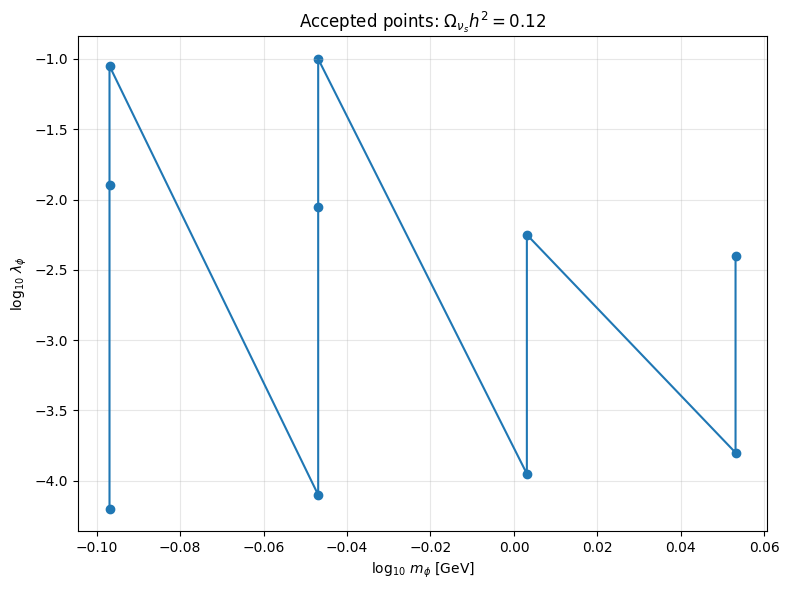

In [ ]:
# plot only accepted points
fig, ax = plt.subplots(figsize=(8, 6))
if accepted:
    acc = np.array(accepted)
    lam_ok, mphi_ok, Om_ok = acc[:,0], acc[:,1], acc[:,2]
    sc = ax.scatter(np.log10(mphi_ok),np.log10(lam_ok))
    sc = ax.plot(np.log10(mphi_ok),np.log10(lam_ok))
    ax.set_ylabel(r"$\log_{10}\,\lambda_\phi$")
    ax.set_xlabel(r"$\log_{10}\,m_\phi\ \mathrm{[GeV]}$")
    ax.set_title(r"Accepted points: $\Omega_{\nu_s} h^2 = 0.12$" )
    ax.grid(True, which="both", alpha=0.3)
else:
    ax.text(0.5, 0.5, "No points found", transform=ax.transAxes, ha="center", va="center")
    ax.set_axis_off()
plt.tight_layout()
plt.show()

In [67]:
import csv

with open("accepted_points.csv", "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["lambda", "mphi", "Omega"])  # header
    writer.writerows(accepted)


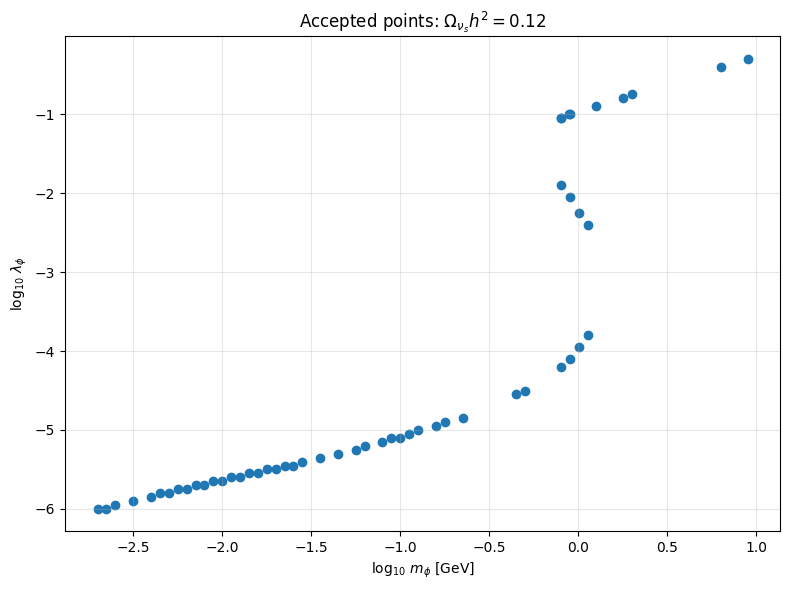

In [83]:
df = pd.read_csv('accepted_points_v3.csv')
mphi_ok = df['mphi']
lam_ok = df['lambda']
# plot only accepted points
fig, ax = plt.subplots(figsize=(8, 6))
if accepted:
    
    sc = ax.scatter(np.log10(mphi_ok),np.log10(lam_ok))
    # sc = ax.plot(np.log10(mphi_ok),np.log10(lam_ok))
    ax.set_ylabel(r"$\log_{10}\,\lambda_\phi$")
    ax.set_xlabel(r"$\log_{10}\,m_\phi\ \mathrm{[GeV]}$")
    ax.set_title(r"Accepted points: $\Omega_{\nu_s} h^2 = 0.12$" )
    ax.grid(True, which="both", alpha=0.3)
else:
    ax.text(0.5, 0.5, "No points found", transform=ax.transAxes, ha="center", va="center")
    ax.set_axis_off()
plt.tight_layout()
plt.show()

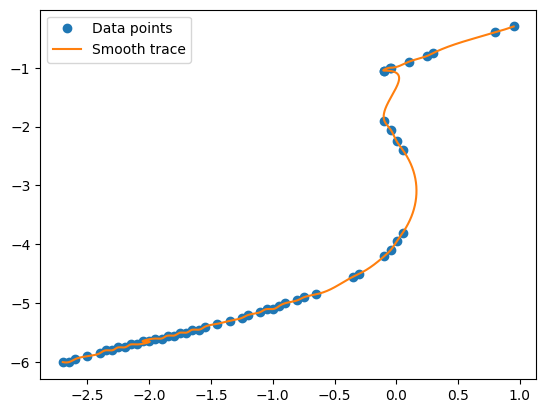

In [79]:
from scipy.interpolate import splprep, splev
df_sort = df.sort_values(by='lambda')
x = np.log10(df_sort['mphi'])
y = np.log10(df_sort['lambda'])
tck, u = splprep([x, y], s=0)   # s=0 means interpolate exactly
unew = np.linspace(0, 1, 1000)   # smooth parameter
xnew, ynew = splev(unew, tck)

# Plot
plt.plot(x, y, 'o', label='Data points')
plt.plot(xnew, ynew, '-', label='Smooth trace')
plt.legend()
plt.show()

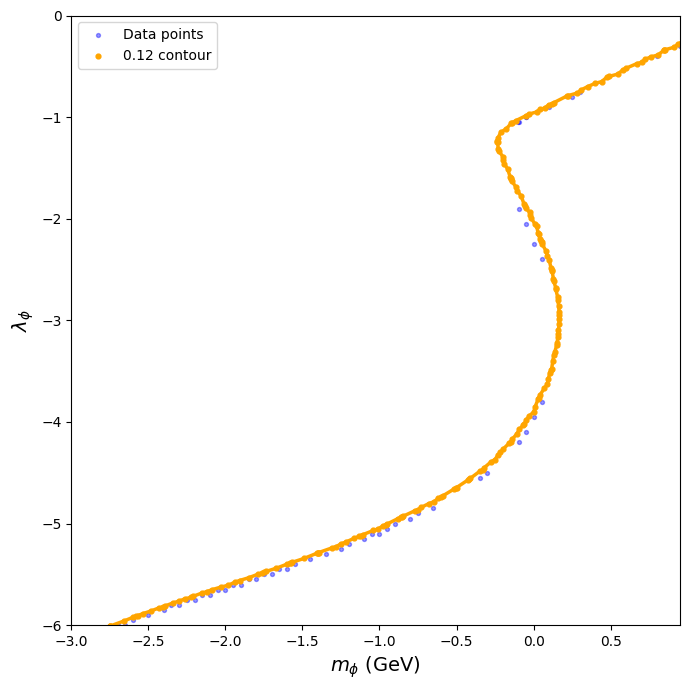

In [92]:
x = np.log10(df_sort['mphi'])
y = np.log10(df_sort['lambda'])

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.tri import Triangulation

# --- 1) Load and transform (match Mathematica logtab) ---
data = np.loadtxt("relicdata_Check_7.1keV.dat")
x_file = data[:, 0]
y_file = data[:, 1]
z_log10 = data[:, 2]

X = y_file                # x-axis in plot
Y = x_file                # y-axis in plot
Z = 10.0 ** z_log10       # values to contour

# --- 2) Compute 0.12 contour ---
tri = Triangulation(X, Y)
level_target = 0.12
fig, ax = plt.subplots(figsize=(7, 7))

cs = ax.tricontour(tri, Z, levels=[level_target], colors="orange", linewidths=2.5)

# Extract contour coordinates
contour_segments = []
for path in cs.collections[0].get_paths():
    contour_segments.append(path.vertices)

contour_points = np.vstack(contour_segments) if contour_segments else np.empty((0, 2))

# --- 3) Plot both scatter sets ---
# raw data
ax.scatter(x,y, s=8, c="blue", alpha=0.4, label="Data points")
# contour
ax.scatter(contour_points[:, 0], contour_points[:, 1], s=12, c="orange", label="0.12 contour")

ax.set_xlim(-3.0, 0.95)
ax.set_ylim(-6.0, 0.0)
ax.set_xlabel(r"$m_{\phi}\ \mathrm{(GeV)}$", fontsize=14)
ax.set_ylabel(r"$\lambda_{\phi}$", fontsize=14)
ax.legend()
plt.tight_layout()
plt.show()

